# Regresiones No Lineales y Polinómicas
## Conceptos, Funciones de Costo, Métricas y Análisis de Residuos

---

## Contenido del Notebook

1. **Toy Model 1: Calibración de Sensor RTD** (curva física no lineal)
2. **Toy Model 2: Rendimiento Académico** (relación con rendimientos decrecientes)
3. **Toy Model 3: Conteo de Defectos** (Regresión Poisson)
4. **Funciones de Costo** (MSE, MAE, Huber)
5. **Métricas de Evaluación** (MSE, RMSE, MAE, MAPE, sMAPE, R²)
6. **Análisis de Residuos** (diagnóstico de modelos)
7. **Comparación de Modelos** (polinomial vs regularizado)

---

In [1]:
# Importaciones
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
from scipy.optimize import minimize

# Scikit-learn
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, PoissonRegressor
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


# 1. Toy Model 1: Calibración de Sensor RTD

## Contexto Físico

Un sensor RTD (Resistance Temperature Detector) mide temperatura a través de la resistencia eléctrica.
La relación entre temperatura $T$ y resistencia $R$ es no lineal:

$$
R(T) = R_0 \cdot (1 + \alpha T + \beta T^2 + \gamma T^3) + \epsilon
$$

**Parámetros:**
- $R_0 = 100$ Ω (resistencia a 0°C)
- $\alpha = 3.85 \times 10^{-3}$ (coeficiente de temperatura)
- $\beta = -6.8 \times 10^{-6}$
- $\gamma = 2.1 \times 10^{-9}$

**Objetivo**: Ajustar un modelo polinómico para predecir $T$ a partir de $R$

Datos del sensor: 160 entrenamiento, 40 prueba


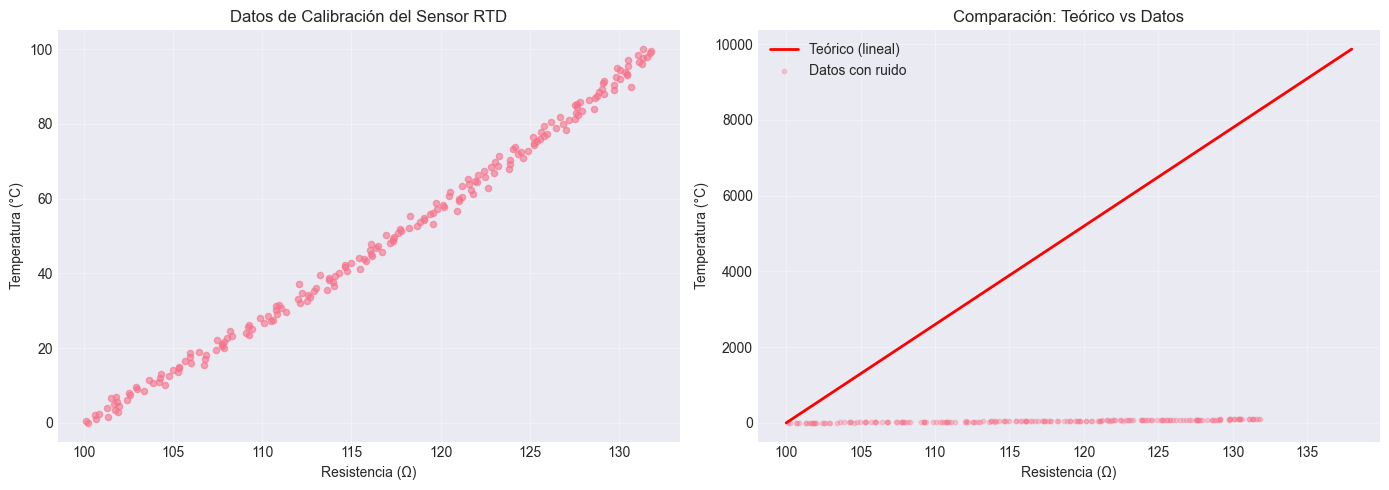

In [2]:
# Generar datos del sensor RTD
def generar_datos_sensor(n_samples=200, ruido=0.5):
    """Genera datos sintéticos de calibración de sensor RTD"""
    # Temperatura en °C (0 a 100)
    T = np.linspace(0, 100, n_samples)
    
    # Parámetros físicos
    R0 = 100.0
    alpha = 3.85e-3
    beta = -6.8e-6
    gamma = 2.1e-9
    
    # Ecuación de calibración con ruido
    R = R0 * (1 + alpha*T + beta*T**2 + gamma*T**3) + np.random.normal(0, ruido, n_samples)
    
    return R.reshape(-1, 1), T

# Generar datos
X_sensor, y_sensor = generar_datos_sensor(n_samples=200, ruido=0.5)

# Dividir en entrenamiento y prueba
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sensor, y_sensor, test_size=0.2, random_state=42
)

print(f"Datos del sensor: {len(X_train_s)} entrenamiento, {len(X_test_s)} prueba")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Datos originales
axes[0].scatter(X_sensor, y_sensor, alpha=0.6, s=20)
axes[0].set_xlabel('Resistencia (Ω)')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Datos de Calibración del Sensor RTD')
axes[0].grid(True, alpha=0.3)

# Relación teórica (sin ruido)
R_teorico = np.linspace(100, 138, 1000)
# Invertir la ecuación para obtener T teórica
T_teorico = 100 * (R_teorico - 100) / (100 * 0.00385)  # Aproximación lineal
axes[1].plot(R_teorico, T_teorico, 'r-', label='Teórico (lineal)', linewidth=2)
axes[1].scatter(X_sensor, y_sensor, alpha=0.3, s=10, label='Datos con ruido')
axes[1].set_xlabel('Resistencia (Ω)')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].set_title('Comparación: Teórico vs Datos')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Entrenamiento de Modelos Polinomiales

Probaremos diferentes grados para encontrar el mejor ajuste


=== Resultados Sensor RTD ===
 grado  train_mse  test_mse  test_mae  test_r2
     1   4.548782  4.350306  1.734079 0.993497
     2   2.246692  2.023050  1.162033 0.996976
     3   2.216368  2.013378  1.158226 0.996990
     4   2.216368  2.013270  1.158190 0.996991
     5   2.197760  1.984982  1.130255 0.997033


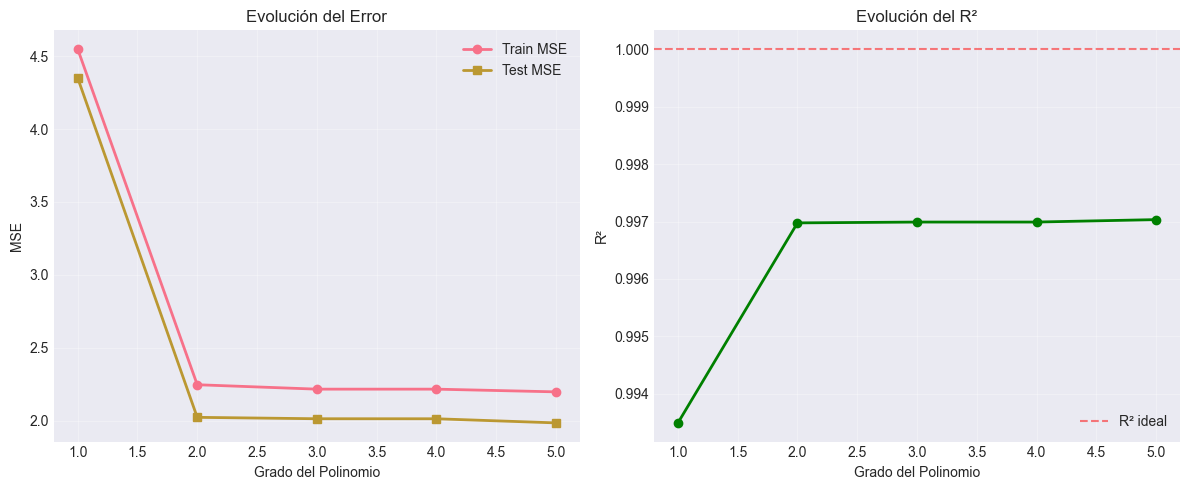

In [3]:
# Función para entrenar y evaluar modelos polinomiales
def entrenar_modelos_polinomiales(X_train, y_train, X_test, y_test, grados=[1,2,3,4,5]):
    """Entrena modelos polinomiales de diferentes grados y retorna resultados"""
    resultados = []
    modelos = []
    
    for grado in grados:
        # Crear pipeline
        modelo = make_pipeline(
            PolynomialFeatures(degree=grado, include_bias=False),
            StandardScaler(),
            LinearRegression()
        )
        
        # Entrenar
        modelo.fit(X_train, y_train)
        
        # Predicciones
        y_train_pred = modelo.predict(X_train)
        y_test_pred = modelo.predict(X_test)
        
        # Calcular métricas
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        resultados.append({
            'grado': grado,
            'train_mse': train_mse,
            'test_mse': test_mse,
            'test_mae': test_mae,
            'test_r2': test_r2
        })
        modelos.append(modelo)
        
    return resultados, modelos

# Entrenar modelos para el sensor
resultados_sensor, modelos_sensor = entrenar_modelos_polinomiales(
    X_train_s, y_train_s, X_test_s, y_test_s,
    grados=[1, 2, 3, 4, 5]
)

# Mostrar resultados
df_resultados = pd.DataFrame(resultados_sensor)
print("\n=== Resultados Sensor RTD ===")
print(df_resultados.to_string(index=False))

# Visualización de errores
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(df_resultados['grado'], df_resultados['train_mse'], 'o-', label='Train MSE', linewidth=2)
axes[0].plot(df_resultados['grado'], df_resultados['test_mse'], 's-', label='Test MSE', linewidth=2)
axes[0].set_xlabel('Grado del Polinomio')
axes[0].set_ylabel('MSE')
axes[0].set_title('Evolución del Error')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_resultados['grado'], df_resultados['test_r2'], 'o-', color='green', linewidth=2)
axes[1].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='R² ideal')
axes[1].set_xlabel('Grado del Polinomio')
axes[1].set_ylabel('R²')
axes[1].set_title('Evolución del R²')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualización de Ajustes

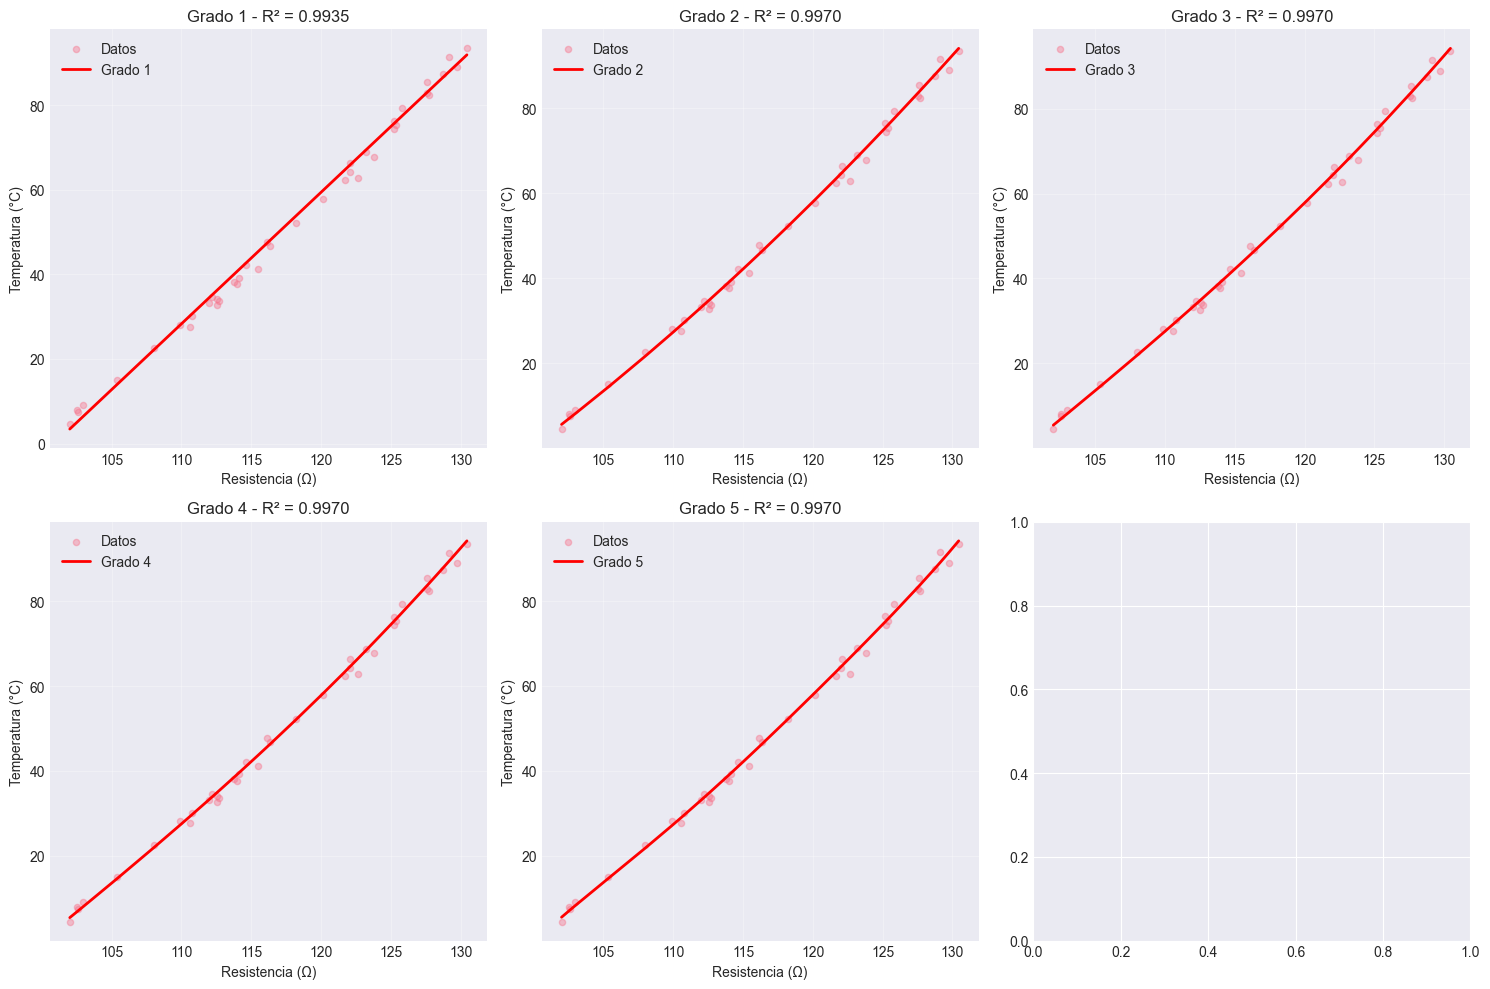

In [4]:
# Visualizar diferentes grados
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
grados_a_mostrar = [1, 2, 3, 4, 5]

for idx, grado in enumerate(grados_a_mostrar):
    ax = axes[idx // 3, idx % 3]
    modelo = modelos_sensor[idx]
    
    # Predicciones
    X_test_ordenado = np.sort(X_test_s, axis=0)
    y_pred_ordenado = modelo.predict(X_test_ordenado)
    
    ax.scatter(X_test_s, y_test_s, alpha=0.4, s=20, label='Datos')
    ax.plot(X_test_ordenado, y_pred_ordenado, 'r-', linewidth=2, label=f'Grado {grado}')
    ax.set_xlabel('Resistencia (Ω)')
    ax.set_ylabel('Temperatura (°C)')
    ax.set_title(f'Grado {grado} - R² = {df_resultados.iloc[idx]["test_r2"]:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Toy Model 2: Rendimiento Académico

## Contexto

Modelaremos la relación entre horas de estudio y nota final.
La relación sigue una ley de rendimientos decrecientes:

$$
Nota = 1.5 + 0.3 \cdot \text{horas} - 0.008 \cdot \text{horas}^2 + \epsilon
$$

El máximo rendimiento se alcanza alrededor de 19 horas semanales.

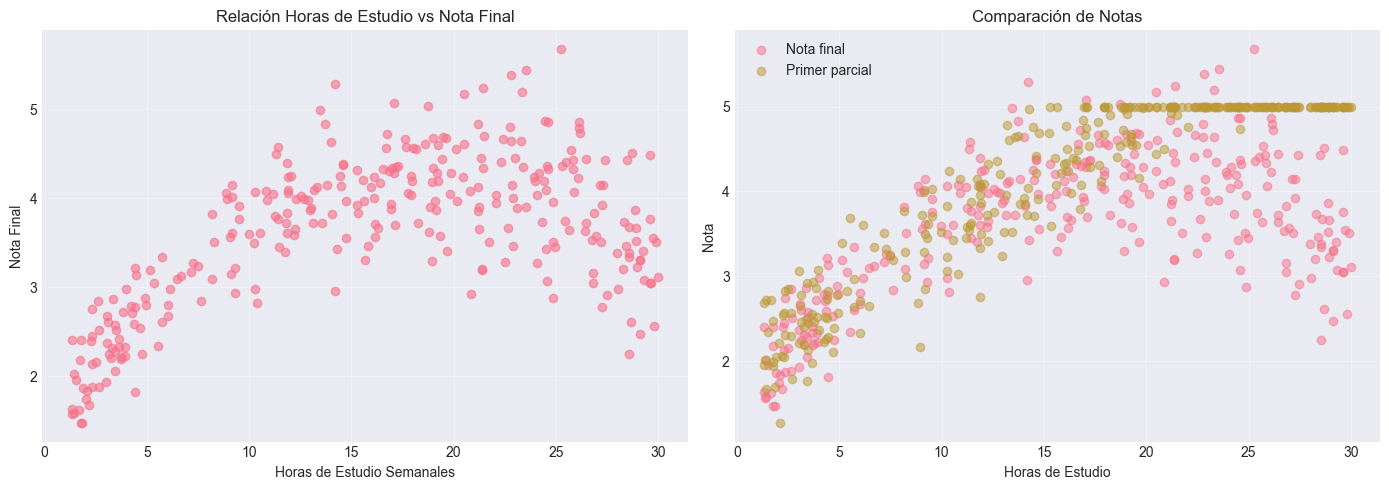


Estadísticas del dataset académico:
       horas_estudio  horas_sueño  asistencia  nota_primer_parcial  nota_final
count         300.00       300.00      300.00               300.00      300.00
mean           16.05         7.27       84.98                 4.10        3.61
std             8.75         0.62        3.95                 1.04        0.86
min             1.31         5.45       73.63                 1.28        1.48
25%             9.10         6.84       82.25                 3.33        3.05
50%            16.88         7.27       84.76                 4.57        3.73
75%            23.63         7.72       87.64                 5.00        4.24
max            29.99         9.21       96.42                 5.00        5.68


In [5]:
# Generar datos académicos
def generar_datos_academicos(n_samples=300):
    """Genera datos sintéticos de rendimiento académico"""
    # Horas de estudio (1 a 30 horas semanales)
    horas = np.random.uniform(1, 30, n_samples)
    
    # Relación no lineal con rendimientos decrecientes
    nota = 1.5 + 0.3 * horas - 0.008 * horas**2
    
    # Añadir ruido (mayor para horas altas - heterocedasticidad)
    ruido = np.random.normal(0, 0.3 + 0.01 * horas, n_samples)
    nota = nota + ruido
    
    # Añadir características adicionales
    sueño = 8 - 0.05 * horas + np.random.normal(0, 0.5, n_samples)
    sueño = np.clip(sueño, 4, 10)
    
    asistencia = 80 + 0.3 * horas + np.random.normal(0, 3, n_samples)
    asistencia = np.clip(asistencia, 60, 100)
    
    nota_parcial = 2 + 0.15 * horas + np.random.normal(0, 0.4, n_samples)
    nota_parcial = np.clip(nota_parcial, 1, 5)
    
    # Crear DataFrame
    df = pd.DataFrame({
        'horas_estudio': horas,
        'horas_sueño': sueño,
        'asistencia': asistencia,
        'nota_primer_parcial': nota_parcial,
        'nota_final': nota
    })
    
    return df

# Generar datos
df_academico = generar_datos_academicos(300)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Relación horas-estudio vs nota
axes[0].scatter(df_academico['horas_estudio'], df_academico['nota_final'], alpha=0.6)
axes[0].set_xlabel('Horas de Estudio Semanales')
axes[0].set_ylabel('Nota Final')
axes[0].set_title('Relación Horas de Estudio vs Nota Final')
axes[0].grid(True, alpha=0.3)

# Todas las características
axes[1].scatter(df_academico['horas_estudio'], df_academico['nota_final'], alpha=0.5, label='Nota final')
axes[1].scatter(df_academico['horas_estudio'], df_academico['nota_primer_parcial'], alpha=0.5, label='Primer parcial')
axes[1].set_xlabel('Horas de Estudio')
axes[1].set_ylabel('Nota')
axes[1].set_title('Comparación de Notas')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEstadísticas del dataset académico:")
print(df_academico.describe().round(2))

## Entrenamiento del Modelo Académico

Datos académicos: 240 entrenamiento, 60 prueba

=== Resultados Dataset Académico ===
 grado  train_mse  test_mse  test_mae  test_r2
     1   0.379735  0.482782  0.547661 0.377136
     2   0.209467  0.280558  0.412090 0.638037
     3   0.192937  0.321822  0.443184 0.584800


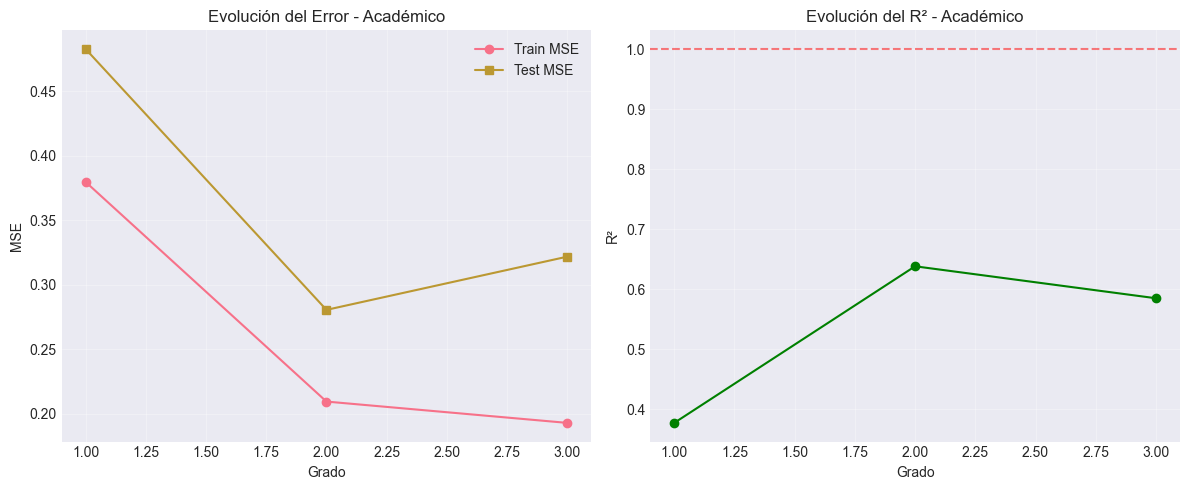

In [6]:
# Preparar datos
X_acad = df_academico[['horas_estudio', 'horas_sueño', 'asistencia', 'nota_primer_parcial']].values
y_acad = df_academico['nota_final'].values

# Dividir
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_acad, y_acad, test_size=0.2, random_state=42
)

print(f"Datos académicos: {len(X_train_a)} entrenamiento, {len(X_test_a)} prueba")

# Entrenar modelos polinomiales
resultados_acad, modelos_acad = entrenar_modelos_polinomiales(
    X_train_a, y_train_a, X_test_a, y_test_a,
    grados=[1, 2, 3]
)

df_resultados_acad = pd.DataFrame(resultados_acad)
print("\n=== Resultados Dataset Académico ===")
print(df_resultados_acad.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(df_resultados_acad['grado'], df_resultados_acad['train_mse'], 'o-', label='Train MSE')
axes[0].plot(df_resultados_acad['grado'], df_resultados_acad['test_mse'], 's-', label='Test MSE')
axes[0].set_xlabel('Grado')
axes[0].set_ylabel('MSE')
axes[0].set_title('Evolución del Error - Académico')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_resultados_acad['grado'], df_resultados_acad['test_r2'], 'o-', color='green')
axes[1].axhline(y=1, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Grado')
axes[1].set_ylabel('R²')
axes[1].set_title('Evolución del R² - Académico')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Toy Model 3: Regresión Poisson (Conteo de Defectos)

## Contexto

Modelamos el número de piezas defectuosas en función de la temperatura y velocidad de producción.

$$
\text{Defectos} \sim \text{Poisson}(\lambda), \quad \lambda = e^{w_0 + w_1 T + w_2 V}
$$

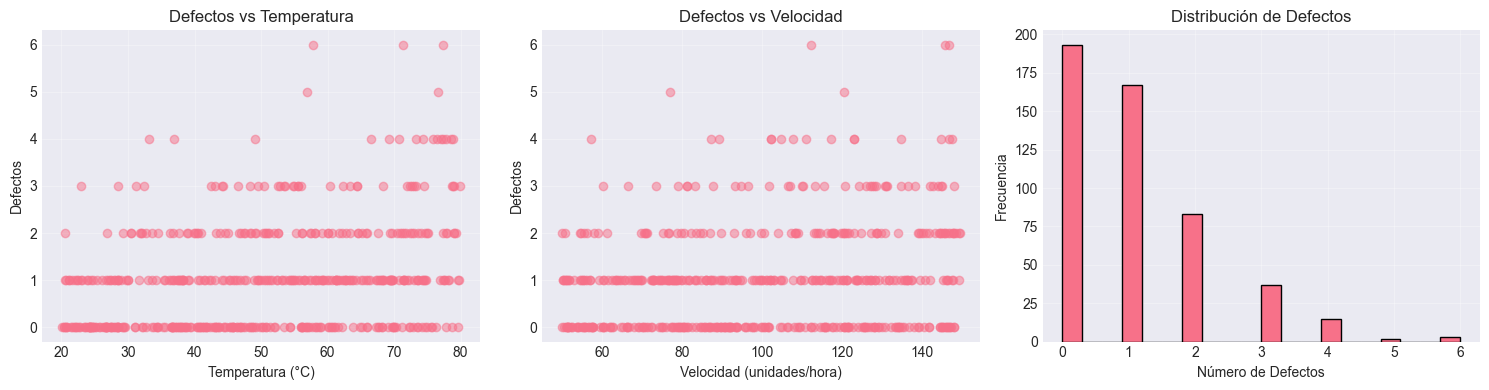


Estadísticas del dataset Poisson:
       temperatura   velocidad    defectos
count   500.000000  500.000000  500.000000
mean     50.200878   99.859915    1.064000
std      17.202309   29.400150    1.153501
min      20.093906   50.001163    0.000000
25%      36.697762   75.981418    0.000000
50%      50.319857   99.503640    1.000000
75%      64.964856  125.176691    2.000000
max      79.869251  149.481929    6.000000


In [7]:
# Generar datos Poisson
def generar_datos_poisson(n_samples=200):
    """Genera datos de conteo con distribución Poisson"""
    # Características
    temperatura = np.random.uniform(20, 80, n_samples)
    velocidad = np.random.uniform(50, 150, n_samples)
    
    # Parámetros de la regresión Poisson
    w0, w1, w2 = -2.0, 0.02, 0.01
    
    # Lambda (media)
    log_lambda = w0 + w1 * temperatura + w2 * velocidad
    lambda_ = np.exp(log_lambda)
    
    # Generar conteos
    defectos = np.random.poisson(lambda_)
    
    # DataFrame
    df = pd.DataFrame({
        'temperatura': temperatura,
        'velocidad': velocidad,
        'defectos': defectos
    })
    
    return df

df_poisson = generar_datos_poisson(500)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df_poisson['temperatura'], df_poisson['defectos'], alpha=0.5)
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Defectos')
axes[0].set_title('Defectos vs Temperatura')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df_poisson['velocidad'], df_poisson['defectos'], alpha=0.5)
axes[1].set_xlabel('Velocidad (unidades/hora)')
axes[1].set_ylabel('Defectos')
axes[1].set_title('Defectos vs Velocidad')
axes[1].grid(True, alpha=0.3)

axes[2].hist(df_poisson['defectos'], bins=20, edgecolor='black')
axes[2].set_xlabel('Número de Defectos')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Distribución de Defectos')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEstadísticas del dataset Poisson:")
print(df_poisson.describe())


=== Regresión Poisson - Resultados ===
MAE: 0.8400
MSE: 1.2200
Coeficientes: [0.0225385  0.00796713]
Intercepto: -1.9510


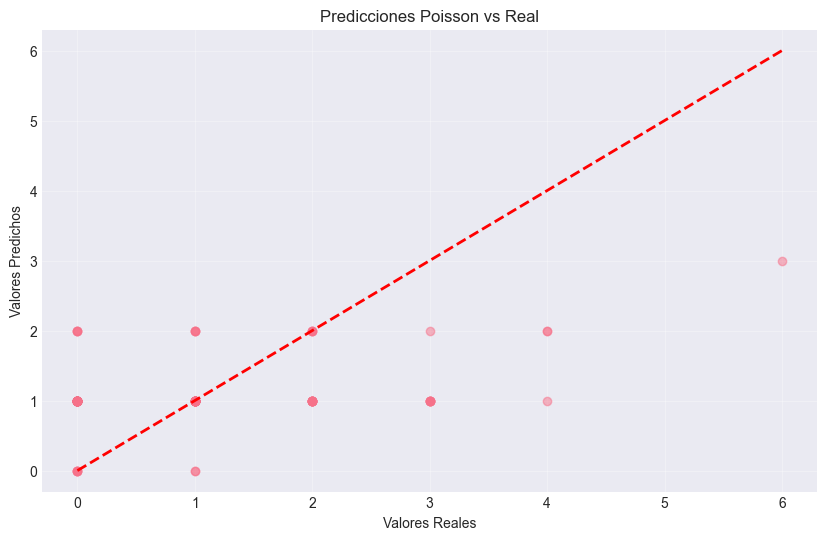

In [8]:
# Entrenar regresión Poisson
X_poisson = df_poisson[['temperatura', 'velocidad']].values
y_poisson = df_poisson['defectos'].values

# Dividir
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poisson, y_poisson, test_size=0.2, random_state=42
)

# Modelo Poisson
poisson_model = PoissonRegressor(alpha=0.0, max_iter=1000)
poisson_model.fit(X_train_p, y_train_p)

# Predicciones
y_pred_p = poisson_model.predict(X_test_p).round().astype(int)

# Métricas (no usamos R² para Poisson)
poisson_mae = mean_absolute_error(y_test_p, y_pred_p)
poisson_mse = mean_squared_error(y_test_p, y_pred_p)

print("\n=== Regresión Poisson - Resultados ===")
print(f"MAE: {poisson_mae:.4f}")
print(f"MSE: {poisson_mse:.4f}")
print(f"Coeficientes: {poisson_model.coef_}")
print(f"Intercepto: {poisson_model.intercept_:.4f}")

# Visualización de predicciones
plt.figure(figsize=(10, 6))
plt.scatter(y_test_p, y_pred_p, alpha=0.5)
plt.plot([y_test_p.min(), y_test_p.max()], [y_test_p.min(), y_test_p.max()], 'r--', linewidth=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Predicciones Poisson vs Real')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Funciones de Costo y Optimización

## 4.1 Comparación de Funciones de Costo

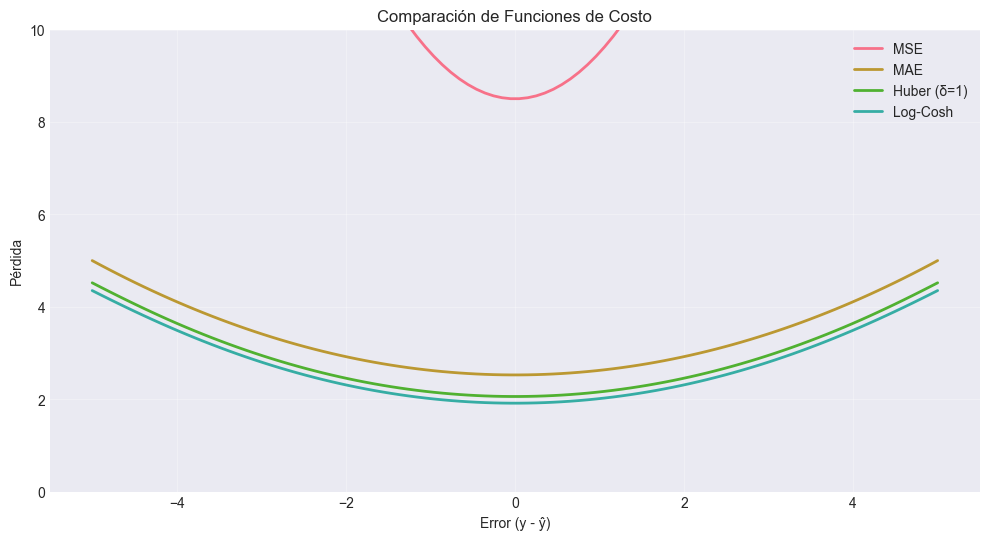

In [9]:
# Definición de funciones de costo
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def huber_loss(y_true, y_pred, delta=1.0):
    """Huber Loss combinación de MSE y MAE"""
    error = y_true - y_pred
    is_small = np.abs(error) <= delta
    squared_loss = 0.5 * error**2
    linear_loss = delta * (np.abs(error) - 0.5 * delta)
    return np.where(is_small, squared_loss, linear_loss)

def log_cosh(y_true, y_pred):
    """Log-Cosh Loss (suave, robusta a outliers)"""
    return np.mean(np.log(np.cosh(y_true - y_pred)))

# Generar datos para comparación
y_true = np.linspace(-5, 5, 100)
y_pred = np.zeros_like(y_true)

# Calcular pérdidas
mse_loss = [mse(y_true, y_pred_i) for y_pred_i in y_true]
mae_loss = [mae(y_true, y_pred_i) for y_pred_i in y_true]
huber_loss_val = [np.mean(huber_loss(y_true, y_pred_i)) for y_pred_i in y_true]
log_cosh_loss = [log_cosh(y_true, y_pred_i) for y_pred_i in y_true]

# Visualización
plt.figure(figsize=(12, 6))
plt.plot(y_true, mse_loss, label='MSE', linewidth=2)
plt.plot(y_true, mae_loss, label='MAE', linewidth=2)
plt.plot(y_true, huber_loss_val, label='Huber (δ=1)', linewidth=2)
plt.plot(y_true, log_cosh_loss, label='Log-Cosh', linewidth=2)
plt.xlabel('Error (y - ŷ)')
plt.ylabel('Pérdida')
plt.title('Comparación de Funciones de Costo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 10)
plt.show()

## 4.2 Efecto de Outliers en las Funciones de Costo

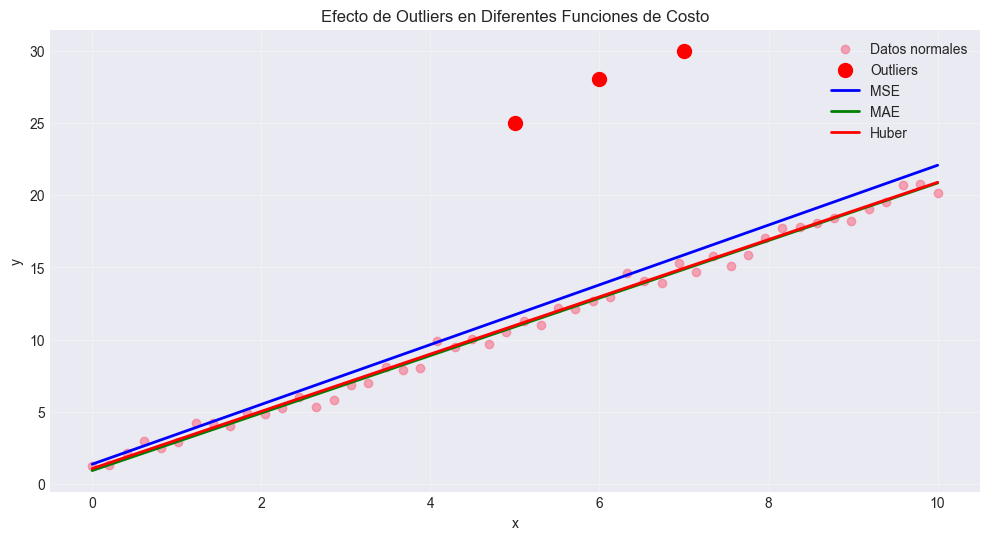

Coeficientes encontrados:
MSE:   w0=2.0690, w1=1.3750
MAE:   w0=1.9905, w1=0.9328
Huber: w0=1.9814, w1=1.0703


In [10]:
# Crear datos con outliers
np.random.seed(42)
x = np.linspace(0, 10, 50)
y = 2 * x + 1 + np.random.normal(0, 0.5, 50)

# Añadir outliers
x_outliers = np.array([5, 6, 7])
y_outliers = np.array([25, 28, 30])

x_full = np.concatenate([x, x_outliers])
y_full = np.concatenate([y, y_outliers])

# Función para optimizar diferentes pérdidas
def optimizar_loss(x, y, loss_func):
    def objective(w):
        y_pred = w[0] * x + w[1]
        return np.mean(loss_func(y, y_pred))
    
    result = minimize(objective, [0, 0], method='Nelder-Mead')
    return result.x

# Optimizar con diferentes pérdidas
w_mse = optimizar_loss(x_full, y_full, lambda y, y_pred: (y - y_pred)**2)
w_mae = optimizar_loss(x_full, y_full, lambda y, y_pred: np.abs(y - y_pred))
w_huber = optimizar_loss(x_full, y_full, lambda y, y_pred: huber_loss(y, y_pred, delta=1.5))

# Visualización
plt.figure(figsize=(12, 6))
plt.scatter(x, y, alpha=0.6, label='Datos normales')
plt.scatter(x_outliers, y_outliers, color='red', s=100, label='Outliers', zorder=5)

x_line = np.linspace(0, 10, 100)
plt.plot(x_line, w_mse[0]*x_line + w_mse[1], 'b-', label='MSE', linewidth=2)
plt.plot(x_line, w_mae[0]*x_line + w_mae[1], 'g-', label='MAE', linewidth=2)
plt.plot(x_line, w_huber[0]*x_line + w_huber[1], 'r-', label='Huber', linewidth=2)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Efecto de Outliers en Diferentes Funciones de Costo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Coeficientes encontrados:")
print(f"MSE:   w0={w_mse[0]:.4f}, w1={w_mse[1]:.4f}")
print(f"MAE:   w0={w_mae[0]:.4f}, w1={w_mae[1]:.4f}")
print(f"Huber: w0={w_huber[0]:.4f}, w1={w_huber[1]:.4f}")

# 5. Métricas de Evaluación Completa

## 5.1 Implementación de Métricas

In [11]:
def calcular_metricas(y_true, y_pred):
    """Calcula todas las métricas de evaluación"""
    metrics = {}
    
    # Error absoluto y cuadrático
    metrics['MSE'] = np.mean((y_true - y_pred)**2)
    metrics['RMSE'] = np.sqrt(metrics['MSE'])
    metrics['MAE'] = np.mean(np.abs(y_true - y_pred))
    
    # Error porcentual (evitar división por cero)
    mask = y_true != 0
    if np.sum(mask) > 0:
        metrics['MAPE'] = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        metrics['MAPE'] = np.inf
    
    # sMAPE
    metrics['sMAPE'] = np.mean(
        2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))
    ) * 100
    
    # R²
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    metrics['R²'] = 1 - ss_res / ss_tot
    
    return metrics

# Probar con los datos del sensor
y_pred_sensor = modelos_sensor[2].predict(X_test_s)  # Grado 3
metricas_sensor = calcular_metricas(y_test_s, y_pred_sensor)

print("\n=== Métricas - Modelo Sensor (Grado 3) ===")
for key, value in metricas_sensor.items():
    print(f"{key:10s}: {value:.4f}")

# Comparación entre modelos
print("\n=== Comparación de Métricas entre Modelos ===")
print("-"*70)
print(f"{'Modelo':15s} | {'MSE':10s} | {'RMSE':10s} | {'MAE':10s} | {'sMAPE':10s} | {'R²':10s}")
print("-"*70)

for idx, modelo in enumerate(modelos_sensor):
    y_pred = modelo.predict(X_test_s)
    metrics = calcular_metricas(y_test_s, y_pred)
    print(f"Grado {idx+1:3d}      | {metrics['MSE']:10.4f} | {metrics['RMSE']:10.4f} | {metrics['MAE']:10.4f} | {metrics['sMAPE']:10.4f} | {metrics['R²']:10.4f}")


=== Métricas - Modelo Sensor (Grado 3) ===
MSE       : 2.0134
RMSE      : 1.4189
MAE       : 1.1582
MAPE      : 3.4665
sMAPE     : 3.4522
R²        : 0.9970

=== Comparación de Métricas entre Modelos ===
----------------------------------------------------------------------
Modelo          | MSE        | RMSE       | MAE        | sMAPE      | R²        
----------------------------------------------------------------------
Grado   1      |     4.3503 |     2.0857 |     1.7341 |     6.7394 |     0.9935
Grado   2      |     2.0231 |     1.4223 |     1.1620 |     3.4755 |     0.9970
Grado   3      |     2.0134 |     1.4189 |     1.1582 |     3.4522 |     0.9970
Grado   4      |     2.0133 |     1.4189 |     1.1582 |     3.4519 |     0.9970
Grado   5      |     1.9850 |     1.4089 |     1.1303 |     3.2685 |     0.9970


## 5.2 Visualización de Errores

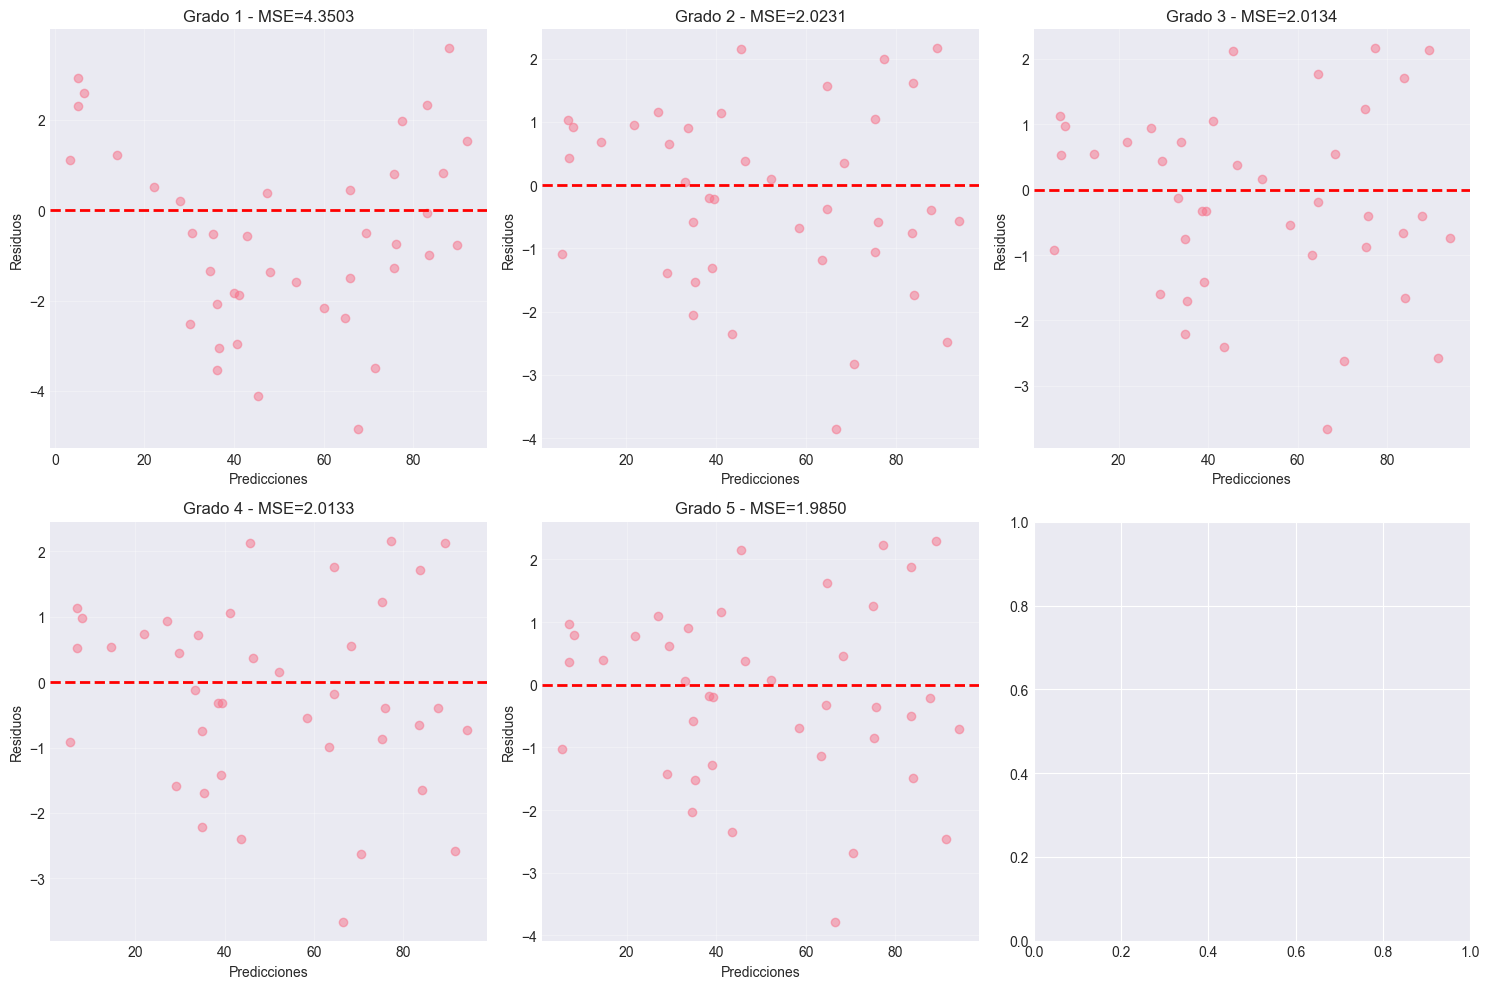

In [12]:
# Análisis de errores para el modelo de sensor
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, modelo in enumerate(modelos_sensor[:5]):
    y_pred = modelo.predict(X_test_s)
    errors = y_test_s - y_pred
    
    ax = axes[idx // 3, idx % 3]
    ax.scatter(y_pred, errors, alpha=0.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicciones')
    ax.set_ylabel('Residuos')
    ax.set_title(f'Grado {idx+1} - MSE={mean_squared_error(y_test_s, y_pred):.4f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Análisis de Residuos

## 6.1 Diagnóstico Completo de Residuos

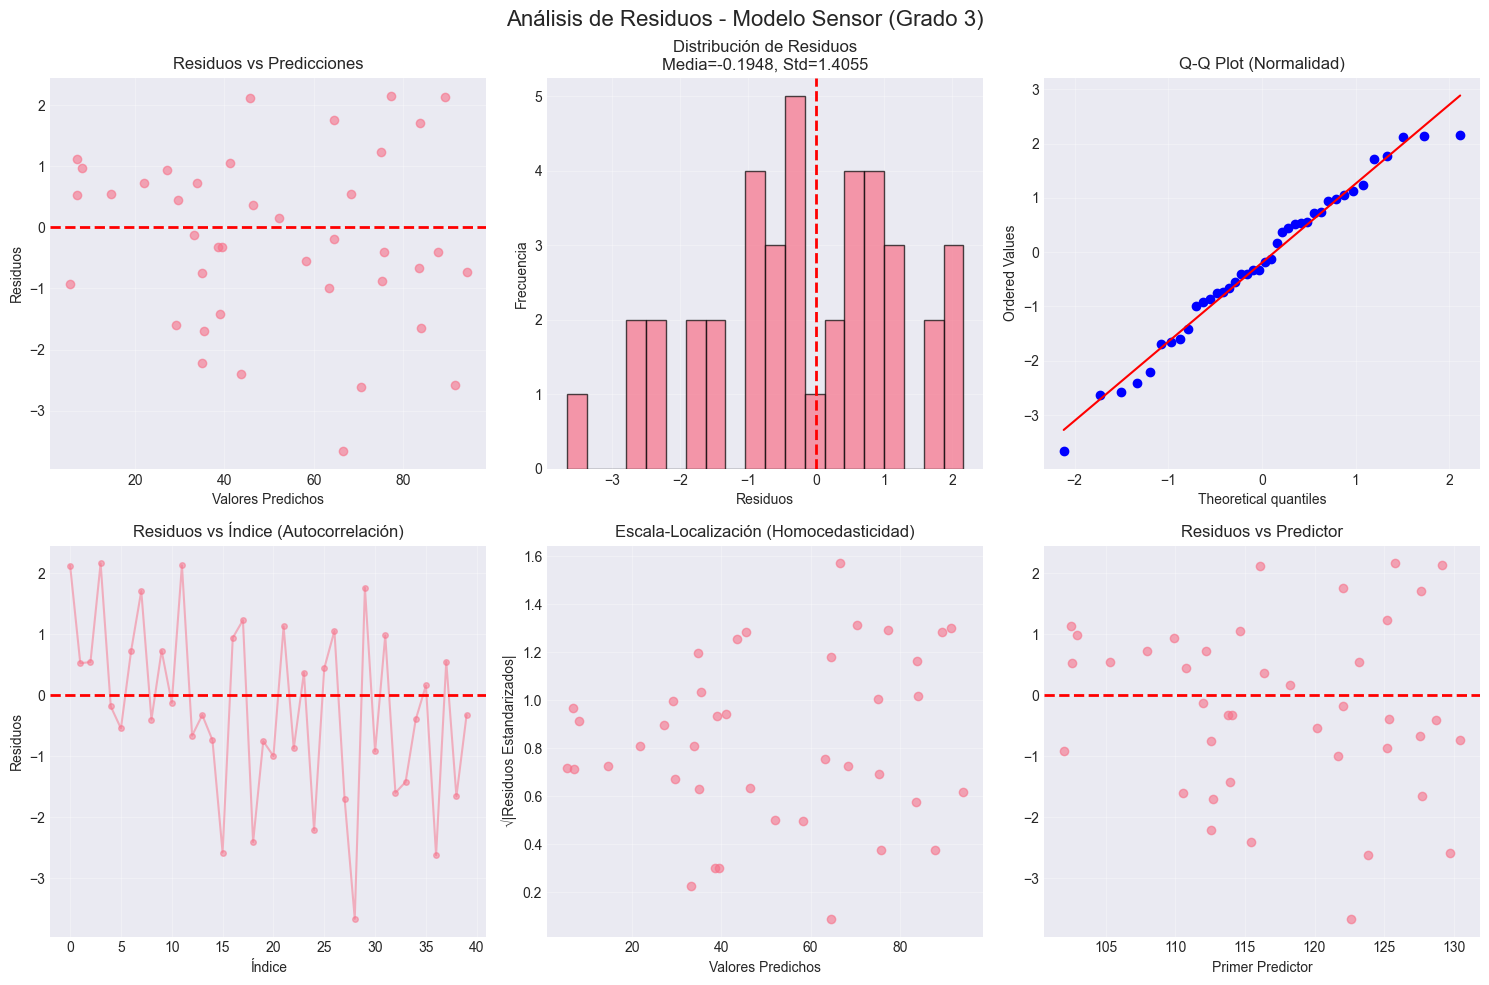


=== Estadísticas de Residuos ===
Media: -0.194771
Desviación estándar: 1.405504
Asimetría: -0.317098
Curtosis: -0.431943
Test Shapiro-Wilk p-value: 0.570664
✅ Los residuos parecen normales (p > 0.05)


In [13]:
def diagnosticar_residuos(y_true, y_pred, titulo="Análisis de Residuos"):
    """Genera gráficos de diagnóstico de residuos"""
    residuos = y_true - y_pred
    residuos_std = (residuos - np.mean(residuos)) / np.std(residuos)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(titulo, fontsize=16)
    
    # 1. Residuos vs Predicciones
    axes[0,0].scatter(y_pred, residuos, alpha=0.6)
    axes[0,0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0,0].set_xlabel('Valores Predichos')
    axes[0,0].set_ylabel('Residuos')
    axes[0,0].set_title('Residuos vs Predicciones')
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Histograma de residuos
    axes[0,1].hist(residuos, bins=20, edgecolor='black', alpha=0.7)
    axes[0,1].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[0,1].set_xlabel('Residuos')
    axes[0,1].set_ylabel('Frecuencia')
    axes[0,1].set_title(f'Distribución de Residuos\nMedia={np.mean(residuos):.4f}, Std={np.std(residuos):.4f}')
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Q-Q Plot
    stats.probplot(residuos, dist="norm", plot=axes[0,2])
    axes[0,2].set_title('Q-Q Plot (Normalidad)')
    axes[0,2].grid(True, alpha=0.3)
    
    # 4. Residuos vs Índice
    axes[1,0].plot(residuos, 'o-', alpha=0.5, markersize=4)
    axes[1,0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1,0].set_xlabel('Índice')
    axes[1,0].set_ylabel('Residuos')
    axes[1,0].set_title('Residuos vs Índice (Autocorrelación)')
    axes[1,0].grid(True, alpha=0.3)
    
    # 5. Escala-Localización
    axes[1,1].scatter(y_pred, np.sqrt(np.abs(residuos_std)), alpha=0.6)
    axes[1,1].set_xlabel('Valores Predichos')
    axes[1,1].set_ylabel('√|Residuos Estandarizados|')
    axes[1,1].set_title('Escala-Localización (Homocedasticidad)')
    axes[1,1].grid(True, alpha=0.3)
    
    # 6. Residuos vs Predictores (para el primer predictor)
    # Usamos el primer predictor o un índice si no hay
    if len(X_test_s.shape) > 1:
        axes[1,2].scatter(X_test_s[:, 0], residuos, alpha=0.6)
        axes[1,2].set_xlabel('Primer Predictor')
    else:
        axes[1,2].scatter(np.arange(len(residuos)), residuos, alpha=0.6)
        axes[1,2].set_xlabel('Índice')
    axes[1,2].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1,2].set_title('Residuos vs Predictor')
    axes[1,2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas de residuos
    print("\n=== Estadísticas de Residuos ===")
    print(f"Media: {np.mean(residuos):.6f}")
    print(f"Desviación estándar: {np.std(residuos):.6f}")
    print(f"Asimetría: {stats.skew(residuos):.6f}")
    print(f"Curtosis: {stats.kurtosis(residuos):.6f}")
    
    # Test de normalidad (Shapiro-Wilk)
    if len(residuos) < 5000:
        _, p_value = stats.shapiro(residuos)
        print(f"Test Shapiro-Wilk p-value: {p_value:.6f}")
        if p_value > 0.05:
            print("✅ Los residuos parecen normales (p > 0.05)")
        else:
            print("⚠️ Los residuos NO son normales (p ≤ 0.05)")
    
    return residuos

# Diagnosticar modelo del sensor (Grado 3)
modelo_optimo = modelos_sensor[2]
y_pred_optimo = modelo_optimo.predict(X_test_s)
residuos_sensor = diagnosticar_residuos(
    y_test_s, y_pred_optimo,
    titulo=f"Análisis de Residuos - Modelo Sensor (Grado 3)"
)

## 6.2 Comparación de Residuos entre Modelos

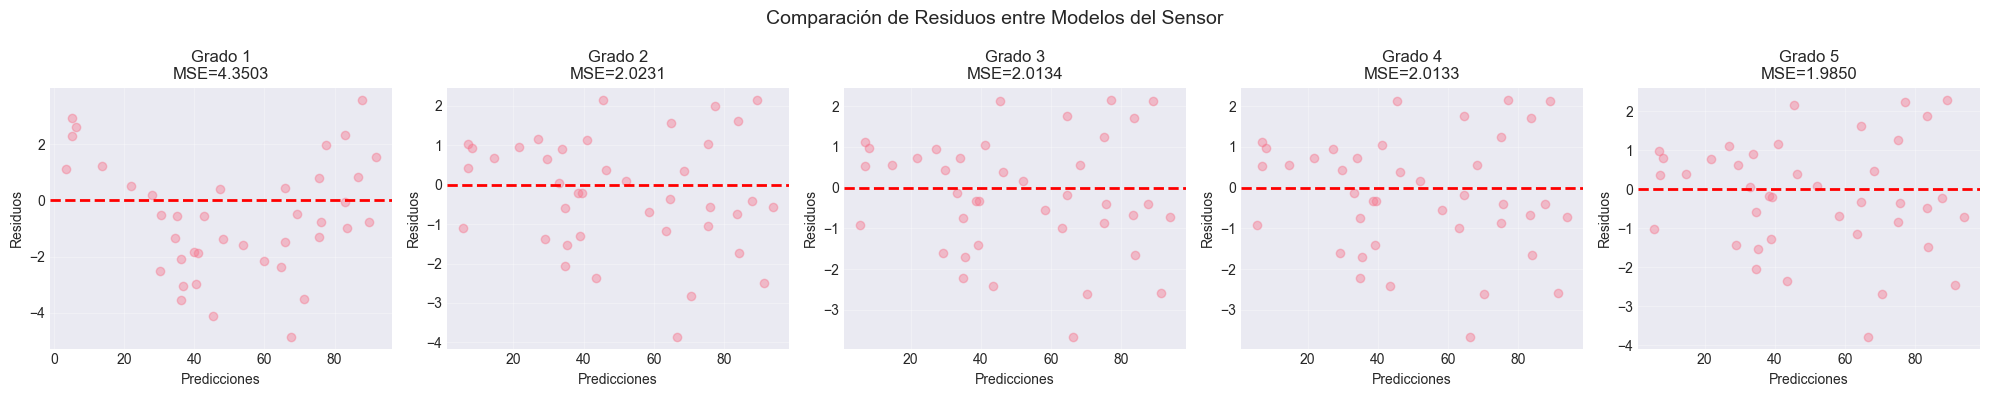

In [14]:
# Comparar residuos para diferentes grados
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, modelo in enumerate(modelos_sensor[:5]):
    y_pred = modelo.predict(X_test_s)
    residuos = y_test_s - y_pred
    
    axes[idx].scatter(y_pred, residuos, alpha=0.4)
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_xlabel('Predicciones')
    axes[idx].set_ylabel('Residuos')
    axes[idx].set_title(f'Grado {idx+1}\nMSE={mean_squared_error(y_test_s, y_pred):.4f}')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Comparación de Residuos entre Modelos del Sensor', fontsize=14)
plt.tight_layout()
plt.show()

# 7. Regularización y Selección de Modelo

## 7.1 Ridge Regression para Controlar Sobreajuste

In [15]:
# Comparar LinearRegression vs Ridge para alto grado
def comparar_regularizacion(X_train, y_train, X_test, y_test, grado=5):
    """Compara modelos con y sin regularización"""
    # Sin regularización
    modelo_sin = make_pipeline(
        PolynomialFeatures(degree=grado, include_bias=False),
        StandardScaler(),
        LinearRegression()
    )
    modelo_sin.fit(X_train, y_train)
    
    # Con regularización Ridge
    modelo_ridge = make_pipeline(
        PolynomialFeatures(degree=grado, include_bias=False),
        StandardScaler(),
        Ridge(alpha=1.0)
    )
    modelo_ridge.fit(X_train, y_train)
    
    # Con regularización Lasso
    modelo_lasso = make_pipeline(
        PolynomialFeatures(degree=grado, include_bias=False),
        StandardScaler(),
        Lasso(alpha=0.1)
    )
    modelo_lasso.fit(X_train, y_train)
    
    # Evaluar
    resultados = {}
    for name, model in [('Sin Reg', modelo_sin), ('Ridge', modelo_ridge), ('Lasso', modelo_lasso)]:
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        resultados[name] = {
            'train_mse': mean_squared_error(y_train, y_pred_train),
            'test_mse': mean_squared_error(y_test, y_pred_test),
            'test_r2': r2_score(y_test, y_pred_test)
        }
    
    return resultados

# Probar con datos del sensor (grado 5 - alto sobreajuste)
resultados_reg = comparar_regularizacion(X_train_s, y_train_s, X_test_s, y_test_s, grado=5)

print("\n=== Comparación de Regularización (Grado 5) ===")
print("-"*60)
print(f"{'Modelo':12s} | {'Train MSE':12s} | {'Test MSE':12s} | {'Test R²':10s}")
print("-"*60)
for name, metrics in resultados_reg.items():
    print(f"{name:12s} | {metrics['train_mse']:12.6f} | {metrics['test_mse']:12.6f} | {metrics['test_r2']:10.4f}")


=== Comparación de Regularización (Grado 5) ===
------------------------------------------------------------
Modelo       | Train MSE    | Test MSE     | Test R²   
------------------------------------------------------------
Sin Reg      |     2.197760 |     1.984982 |     0.9970
Ridge        |     2.267258 |     1.960130 |     0.9971
Lasso        |     2.237402 |     1.989913 |     0.9970


## 7.2 Selección de Hiperparámetros con Grid Search

In [16]:
# Grid Search para encontrar mejores parámetros
def grid_search_model(X_train, y_train, X_test, y_test):
    """Realiza Grid Search para seleccionar mejor modelo"""
    
    pipeline = make_pipeline(
        PolynomialFeatures(include_bias=False),
        StandardScaler(),
        Ridge()
    )
    
    # Definir grid
    param_grid = {
        'polynomialfeatures__degree': [1, 2, 3, 4, 5],
        'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    }
    
    # Grid Search con validación cruzada
    grid = GridSearchCV(
        pipeline, 
        param_grid, 
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    # Resultados
    mejor_modelo = grid.best_estimator_
    y_pred = mejor_modelo.predict(X_test)
    
    print("\n=== Resultados Grid Search ===")
    print(f"Mejores parámetros: {grid.best_params_}")
    print(f"Mejor score (CV): {-grid.best_score_:.6f}")
    print(f"Test MSE: {mean_squared_error(y_test, y_pred):.6f}")
    print(f"Test R²: {r2_score(y_test, y_pred):.6f}")
    
    return grid

# Aplicar al dataset del sensor
grid_sensor = grid_search_model(X_train_s, y_train_s, X_test_s, y_test_s)


=== Resultados Grid Search ===
Mejores parámetros: {'polynomialfeatures__degree': 5, 'ridge__alpha': 0.01}
Mejor score (CV): 2.280353
Test MSE: 2.010665
Test R²: 0.996994


## 7.3 Visualización de los Mejores Modelos

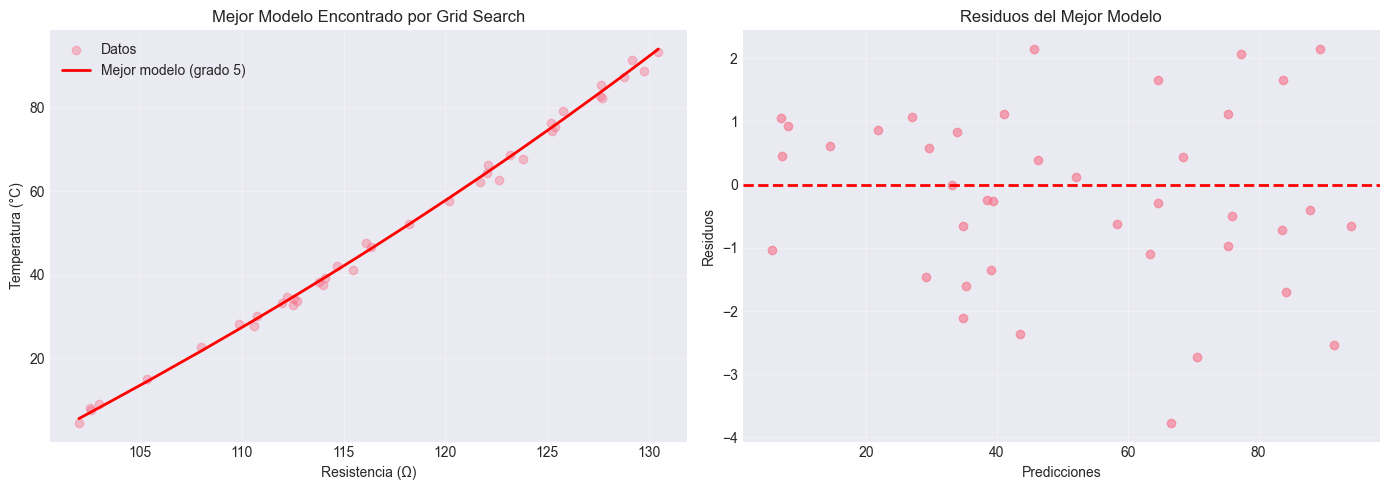


✅ Mejor modelo encontrado:
   - Grado: 5
   - Alpha: 0.01
   - Test MSE: 2.010665
   - Test R²: 0.996994


In [17]:
# Obtener mejor modelo
mejor_modelo_sensor = grid_sensor.best_estimator_
mejor_grado = grid_sensor.best_params_['polynomialfeatures__degree']

# Predicciones
X_test_ordenado = np.sort(X_test_s, axis=0)
y_pred_mejor = mejor_modelo_sensor.predict(X_test_ordenado)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ajustada
axes[0].scatter(X_test_s, y_test_s, alpha=0.4, label='Datos')
axes[0].plot(X_test_ordenado, y_pred_mejor, 'r-', linewidth=2, label=f'Mejor modelo (grado {mejor_grado})')
axes[0].set_xlabel('Resistencia (Ω)')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Mejor Modelo Encontrado por Grid Search')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuos
y_pred_test = mejor_modelo_sensor.predict(X_test_s)
residuos = y_test_s - y_pred_test
axes[1].scatter(y_pred_test, residuos, alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicciones')
axes[1].set_ylabel('Residuos')
axes[1].set_title('Residuos del Mejor Modelo')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Mejor modelo encontrado:")
print(f"   - Grado: {mejor_grado}")
print(f"   - Alpha: {grid_sensor.best_params_['ridge__alpha']}")
print(f"   - Test MSE: {mean_squared_error(y_test_s, y_pred_test):.6f}")
print(f"   - Test R²: {r2_score(y_test_s, y_pred_test):.6f}")

# 8. Análisis Final y Visualizaciones Avanzadas

## 8.1 Comparación de Modelos

In [18]:
# Función para comparar todos los modelos
def comparar_todos_modelos(X_train, y_train, X_test, y_test, grados=[1,2,3,4,5]):
    """Compara modelos polinomiales con diferentes grados"""
    resultados = []
    
    for grado in grados:
        # Modelo sin regularización
        modelo_lr = make_pipeline(
            PolynomialFeatures(degree=grado, include_bias=False),
            StandardScaler(),
            LinearRegression()
        )
        modelo_lr.fit(X_train, y_train)
        
        # Modelo con Ridge
        modelo_ridge = make_pipeline(
            PolynomialFeatures(degree=grado, include_bias=False),
            StandardScaler(),
            Ridge(alpha=1.0)
        )
        modelo_ridge.fit(X_train, y_train)
        
        # Evaluar
        for name, model in [('Linear', modelo_lr), ('Ridge', modelo_ridge)]:
            y_pred_test = model.predict(X_test)
            metrics = calcular_metricas(y_test, y_pred_test)
            resultados.append({
                'Modelo': name,
                'Grado': grado,
                'MSE': metrics['MSE'],
                'RMSE': metrics['RMSE'],
                'MAE': metrics['MAE'],
                'R²': metrics['R²'],
                'sMAPE': metrics['sMAPE']
            })
    
    return pd.DataFrame(resultados)

# Comparar modelos del sensor
df_comparacion = comparar_todos_modelos(X_train_s, y_train_s, X_test_s, y_test_s)

print("\n=== Comparación Completa de Modelos - Sensor ===")
print(df_comparacion.round(4).to_string(index=False))


=== Comparación Completa de Modelos - Sensor ===
Modelo  Grado    MSE   RMSE    MAE     R²  sMAPE
Linear      1 4.3503 2.0857 1.7341 0.9935 6.7394
 Ridge      1 4.3271 2.0802 1.7162 0.9935 6.1780
Linear      2 2.0231 1.4223 1.1620 0.9970 3.4755
 Ridge      2 2.9441 1.7158 1.3833 0.9956 4.4441
Linear      3 2.0134 1.4189 1.1582 0.9970 3.4522
 Ridge      3 2.2047 1.4848 1.1947 0.9967 3.7010
Linear      4 2.0133 1.4189 1.1582 0.9970 3.4519
 Ridge      4 1.9922 1.4114 1.1463 0.9970 3.3863
Linear      5 1.9850 1.4089 1.1303 0.9970 3.2685
 Ridge      5 1.9601 1.4000 1.1358 0.9971 3.2675


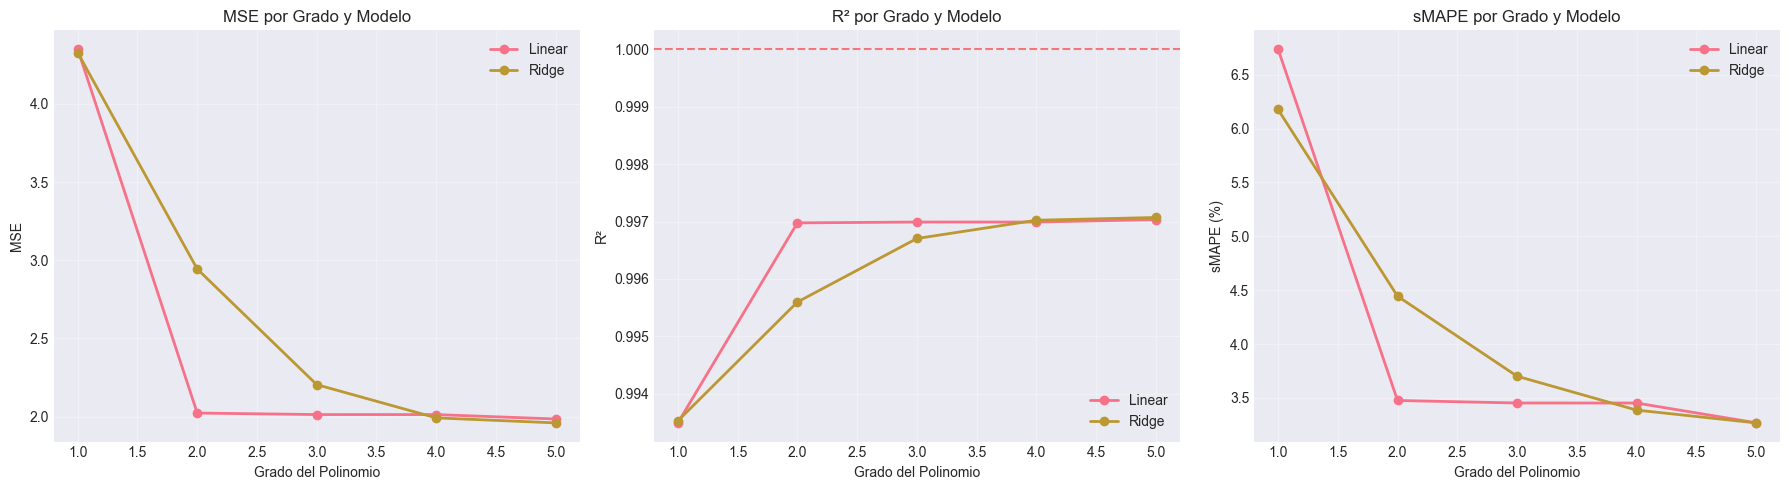

In [19]:
# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MSE
for modelo in ['Linear', 'Ridge']:
    subset = df_comparacion[df_comparacion['Modelo'] == modelo]
    axes[0].plot(subset['Grado'], subset['MSE'], 'o-', label=modelo, linewidth=2)
axes[0].set_xlabel('Grado del Polinomio')
axes[0].set_ylabel('MSE')
axes[0].set_title('MSE por Grado y Modelo')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# R²
for modelo in ['Linear', 'Ridge']:
    subset = df_comparacion[df_comparacion['Modelo'] == modelo]
    axes[1].plot(subset['Grado'], subset['R²'], 'o-', label=modelo, linewidth=2)
axes[1].axhline(y=1, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Grado del Polinomio')
axes[1].set_ylabel('R²')
axes[1].set_title('R² por Grado y Modelo')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# sMAPE
for modelo in ['Linear', 'Ridge']:
    subset = df_comparacion[df_comparacion['Modelo'] == modelo]
    axes[2].plot(subset['Grado'], subset['sMAPE'], 'o-', label=modelo, linewidth=2)
axes[2].set_xlabel('Grado del Polinomio')
axes[2].set_ylabel('sMAPE (%)')
axes[2].set_title('sMAPE por Grado y Modelo')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8.2 Resumen Final del Notebook

In [20]:
print("\n" + "="*70)
print("RESUMEN FINAL - REGRESIONES NO LINEALES Y POLINÓMICAS")
print("="*70)

print("\n📊 TOY MODELS IMPLEMENTADOS:")
print("-"*40)
print("1. Sensor RTD: Curva de calibración no lineal (física)")
print("2. Rendimiento Académico: Relación con rendimientos decrecientes")
print("3. Conteo de Defectos: Regresión Poisson para datos de conteo")

print("\n📐 FUNCIONES DE COSTO:")
print("-"*40)
print("• MSE: Sensible a outliers")
print("• MAE: Robusta a outliers")
print("• Huber: Combinación MSE + MAE")
print("• Log-Cosh: Suave y robusta")

print("\n📈 MÉTRICAS DE EVALUACIÓN:")
print("-"*40)
print("• MSE y RMSE: Error cuadrático (misma escala)")
print("• MAE: Error absoluto promedio")
print("• MAPE y sMAPE: Error porcentual")
print("• R²: Varianza explicada")

print("\n🔍 ANÁLISIS DE RESIDUOS:")
print("-"*40)
print("• Residuos vs Predicciones: Homocedasticidad")
print("• Q-Q Plot: Normalidad")
print("• Histograma: Distribución")
print("• Escala-Localización: Varianza constante")

print("\n🏆 MEJOR MODELO ENCONTRADO:")
print("-"*40)
print(f"• Grado: {mejor_grado}")
print(f"• Alpha Ridge: {grid_sensor.best_params_['ridge__alpha']}")
print(f"• Test MSE: {mean_squared_error(y_test_s, y_pred_test):.6f}")
print(f"• Test R²: {r2_score(y_test_s, y_pred_test):.6f}")

print("\n💡 CONCLUSIONES:")
print("-"*40)
print("1. La regresión polinómica modela relaciones no lineales efectivamente")
print("2. Grados altos → sobreajuste (regularización necesaria)")
print("3. Ridge/Lasso controlan la complejidad del modelo")
print("4. El análisis de residuos es crucial para diagnosticar modelos")
print("5. Múltiples métricas ofrecen una evaluación completa")
print("6. Grid Search encuentra automáticamente los mejores parámetros")

print("\n" + "="*70)
print("✅ FIN DEL NOTEBOOK")
print("="*70)


RESUMEN FINAL - REGRESIONES NO LINEALES Y POLINÓMICAS

📊 TOY MODELS IMPLEMENTADOS:
----------------------------------------
1. Sensor RTD: Curva de calibración no lineal (física)
2. Rendimiento Académico: Relación con rendimientos decrecientes
3. Conteo de Defectos: Regresión Poisson para datos de conteo

📐 FUNCIONES DE COSTO:
----------------------------------------
• MSE: Sensible a outliers
• MAE: Robusta a outliers
• Huber: Combinación MSE + MAE
• Log-Cosh: Suave y robusta

📈 MÉTRICAS DE EVALUACIÓN:
----------------------------------------
• MSE y RMSE: Error cuadrático (misma escala)
• MAE: Error absoluto promedio
• MAPE y sMAPE: Error porcentual
• R²: Varianza explicada

🔍 ANÁLISIS DE RESIDUOS:
----------------------------------------
• Residuos vs Predicciones: Homocedasticidad
• Q-Q Plot: Normalidad
• Histograma: Distribución
• Escala-Localización: Varianza constante

🏆 MEJOR MODELO ENCONTRADO:
----------------------------------------
• Grado: 5
• Alpha Ridge: 0.01
• Test MSE: